In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Load Breast Cancer dataset
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data',
                 header=None)

# Assign column names
df.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion',
                'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']

df.head()


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [6]:
# 1. Data Preprocessing steps
# drop ID column 
data = df.drop(['Sample code'],axis=1)
print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))
data.head()


Number of instances = 699
Number of attributes = 10


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [8]:
# 1.1. missing value handling
data = data.replace('?',np.NaN)
print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of missing values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))


Number of instances = 699
Number of attributes = 10
Number of missing values:
	Clump Thickness: 0
	Uniformity of Cell Size: 0
	Uniformity of Cell Shape: 0
	Marginal Adhesion: 0
	Single Epithelial Cell Size: 0
	Bare Nuclei: 16
	Bland Chromatin: 0
	Normal Nucleoli: 0
	Mitoses: 0
	Class: 0


In [10]:
# Convert 'Bare Nuclei' to numeric
data['Bare Nuclei'] = pd.to_numeric(data['Bare Nuclei'], errors='coerce')

print('Before replacing missing values:')
print(data['Bare Nuclei'][20:25])

data['Bare Nuclei'] = data['Bare Nuclei'].fillna(data['Bare Nuclei'].median())
data['Bare Nuclei'] = data['Bare Nuclei'].dropna() 
print('\nAfter replacing missing values:')
print(data['Bare Nuclei'][20:25])


Before replacing missing values:
20    10.0
21     7.0
22     1.0
23     NaN
24     1.0
Name: Bare Nuclei, dtype: float64

After replacing missing values:
20    10.0
21     7.0
22     1.0
23     1.0
24     1.0
Name: Bare Nuclei, dtype: float64


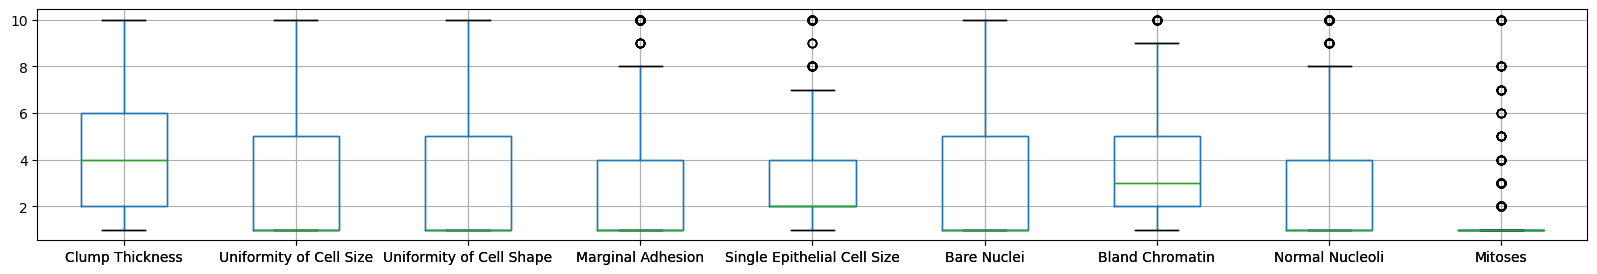

Number of rows before discarding outliers = 699
Number of rows after discarding outliers = 648


In [14]:
# 1.2. handling outliers
# created box plot to find where are more outlier
%matplotlib inline

data_numeric = data.drop(['Class'], axis=1)
data_numeric.boxplot(figsize=(20,3))
#plt.savefig('boxplot.png')
plt.show()

# Standardisation process - to discard outliers compute Z-Score to remove outliers, discarding columns with  Z>3 or Z< -3
Z = (data_numeric - data_numeric.mean()) / data_numeric.std()

print('Number of rows before discarding outliers = %d' % (Z.shape[0]))
Z2 = Z.loc[((Z > -3).sum(axis=1) == 9) & ((Z <= 3).sum(axis=1) == 9), :]
print('Number of rows after discarding outliers = %d' % (Z2.shape[0]))


In [16]:
# 1.3. checking duplicate data in dataset
dups = data.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

# removing duplicate rows
print('Number of rows before discarding duplicates = %d' % (data.shape[0]))
data2 = data.drop_duplicates()
print('Number of rows after discarding duplicates = %d' % (data2.shape[0]))


Number of duplicate rows = 242
Number of rows before discarding duplicates = 699
Number of rows after discarding duplicates = 457


In [18]:
# 1.4. data Sampling
sample = data.sample(n=3)
print("Random sample of 5 rows:")
print(sample)


Random sample of 5 rows:
     Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
500                6                        1                         1   
392                3                        1                         1   
319                4                        4                         4   

     Marginal Adhesion  Single Epithelial Cell Size  Bare Nuclei  \
500                  1                            2          1.0   
392                  1                            2          1.0   
319                  4                            6          5.0   

     Bland Chromatin  Normal Nucleoli  Mitoses  Class  
500                3                1        1      2  
392                2                1        1      2  
319                7                3        1      2  


Equal width bins:
Clump Thickness
(0.991, 3.25]    303
(3.25, 5.5]      210
(5.5, 7.75]       57
(7.75, 10.0]     129
Name: count, dtype: int64
Equal frequency bins:
Clump Thickness
(0.999, 2.0]    195
(2.0, 4.0]      188
(4.0, 6.0]      164
(6.0, 10.0]     152
Name: count, dtype: int64


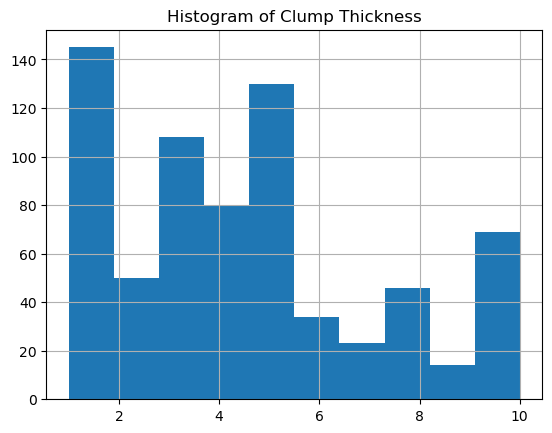

In [20]:
# 2. discretization
bins = pd.cut(data['Clump Thickness'], 4)
print("Equal width bins:")
print(bins.value_counts(sort=False))

bins = pd.qcut(data['Clump Thickness'], 4)
print("Equal frequency bins:")
print(bins.value_counts(sort=False))

data['Clump Thickness'].hist(bins=10)
plt.title('Histogram of Clump Thickness')
#plt.savefig('Histogram of Clump Thickness.png') 
plt.show()


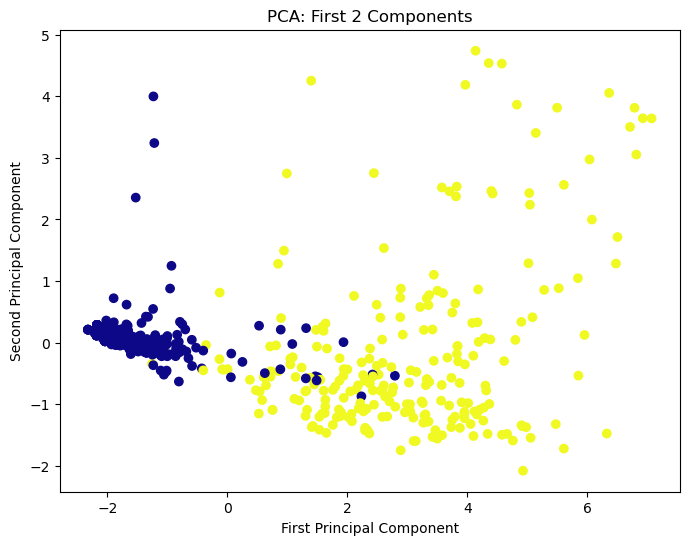

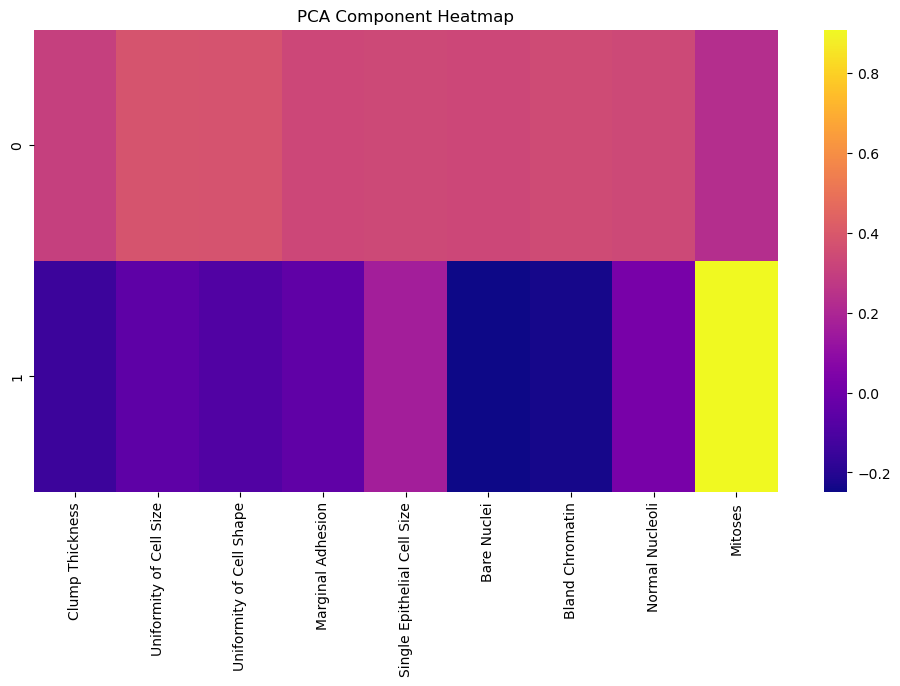

In [22]:
# 3. PCA for Dimensionality Reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data['Class'] = data['Class'].map({2: 0, 4: 1})
features = data.drop(['Class'], axis=1)
target = data['Class']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=target, cmap='plasma')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA: First 2 Components')
#plt.savefig('PCA: First 2 Components.png') 
plt.show()

# PCA Heatmap
import seaborn as sns
df_comp = pd.DataFrame(pca.components_, columns=features.columns)
plt.figure(figsize=(12,6))
sns.heatmap(df_comp, cmap='plasma')
plt.title('PCA Component Heatmap')
#plt.savefig('PCA Component Heatmap.png') 
plt.show()


In [24]:
# 4. Model Comparision
# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(scaled_data, target, test_size=0.3, random_state=42)


Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Tuned SVM Classifier Results:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       143
           1       0.97      0.90      0.93        67

    accuracy                           0.96       210
   macro avg       0.96      0.94      0.95       210
weighted avg       0.96      0.96      0.96       210

[[141   2]
 [  7  60]]


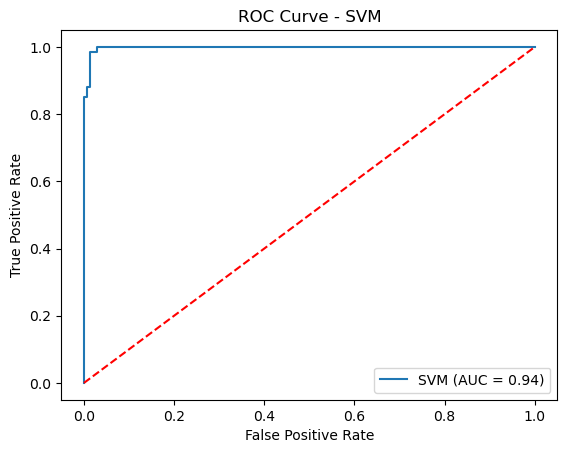

In [26]:
# 4.1. GridSearchCV for SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("Best Parameters for SVM:", grid_svm.best_params_)
print("Tuned SVM Classifier Results:")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

# ROC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, best_svm.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr_svm, tpr_svm, label='SVM (AUC = %.2f)' % roc_auc_score(y_test, y_pred_svm))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
#plt.savefig('ROC Curve - SVM.png') 
plt.show()


Best Parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       143
           1       0.95      0.94      0.95        67

    accuracy                           0.97       210
   macro avg       0.96      0.96      0.96       210
weighted avg       0.97      0.97      0.97       210

[[140   3]
 [  4  63]]


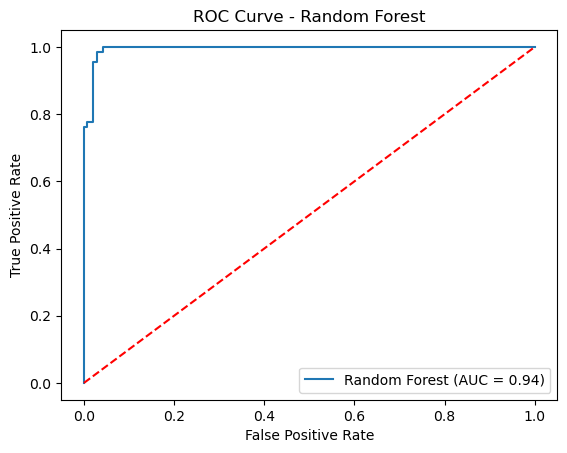

In [28]:
# 4.2. GridSearchCV for Random Forest
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Best Parameters for Random Forest:", grid_rf.best_params_)
print("Tuned Random Forest Classifier Results:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, grid_rf.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %.2f)' % roc_auc_score(y_test, y_pred_svm))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
#plt.savefig('ROC Curve - Random Forest.png') 
plt.show()


Decision Tree Classifier Results:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       143
           1       0.90      0.90      0.90        67

    accuracy                           0.93       210
   macro avg       0.92      0.92      0.92       210
weighted avg       0.93      0.93      0.93       210

[[136   7]
 [  7  60]]


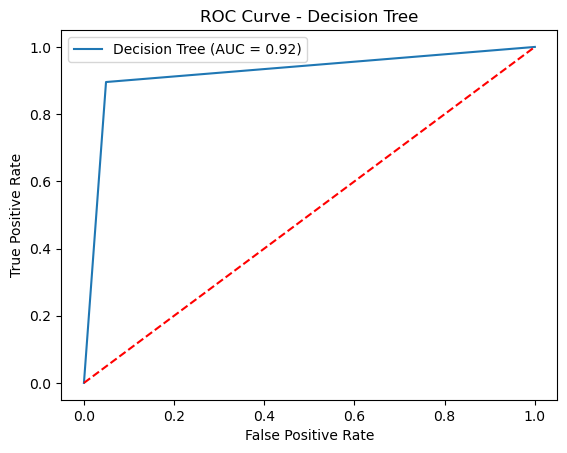

In [30]:
# 4.3. Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("Decision Tree Classifier Results:")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

# ROC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dtree.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr_dt, tpr_dt, label='Decision Tree (AUC = %.2f)' % roc_auc_score(y_test, y_pred_dt))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
#plt.savefig('ROC Curve - Decision Tree.png') 
plt.show()


In [32]:
# 5. Model Comparison Summary
model_names = ['Decision Tree', 'Random Forest (Tuned)', 'SVM (Tuned)']
predictions = [y_pred_dt, y_pred_rf, y_pred_svm]
models_summary = []

for name, preds in zip(model_names, predictions):
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    models_summary.append([name, acc, prec, rec, f1])

summary_df = pd.DataFrame(models_summary, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\nModel Comparison Summary:")
print(summary_df)



Model Comparison Summary:
                   Model  Accuracy  Precision    Recall  F1-Score
0          Decision Tree  0.933333   0.895522  0.895522  0.895522
1  Random Forest (Tuned)  0.966667   0.954545  0.940299  0.947368
2            SVM (Tuned)  0.957143   0.967742  0.895522  0.930233
